In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import layers, models
import numpy as np

In [5]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


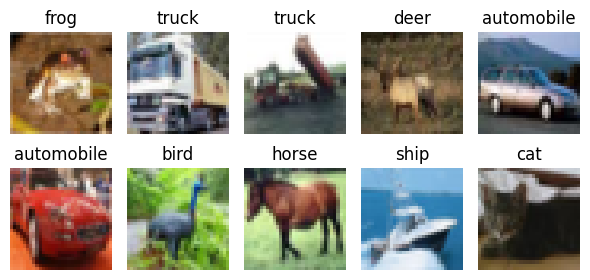

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Class labels
class_names = [
    'airplane','automobile','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
]

plt.figure(figsize=(6,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], interpolation='nearest')
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Normalization


In [8]:
# Normalize pixel values (0–255 → 0–1)

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


**Till now, this processing the image for the traing. it will help for further traning and prediction**

In [9]:
# Build CNN model
model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

# First Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Second Convolution Layer
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(layers.MaxPooling2D((2,2)))

In [11]:
# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(
    64,
    activation='relu'
))

# Output Layer
model.add(layers.Dense(
    10,
    activation='softmax'
))

below Model for improve performance

In [25]:
from tensorflow.keras import layers, models

model2 = models.Sequential()

# First Convolution Block
model2.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model2.add(layers.MaxPooling2D((2,2)))

# Second Convolution Block
model2.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model2.add(layers.MaxPooling2D((2,2)))

# Flatten
model2.add(layers.Flatten())

# Dense Layer
model2.add(layers.Dense(
    64,
    activation='relu'
))

# Dropout Layer (NEW)
model2.add(layers.Dropout(0.5))

# Output Layer
model2.add(layers.Dense(
    10,
    activation='softmax'
))

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4692 - loss: 1.4723 - val_accuracy: 0.5732 - val_loss: 1.2176
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6077 - loss: 1.1203 - val_accuracy: 0.6206 - val_loss: 1.0930
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6574 - loss: 0.9868 - val_accuracy: 0.6665 - val_loss: 0.9744
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6916 - loss: 0.8965 - val_accuracy: 0.6835 - val_loss: 0.9338
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7120 - loss: 0.8318 - val_accuracy: 0.6870 - val_loss: 0.9083
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7301 - loss: 0.7822 - val_accuracy: 0.6945 - val_loss: 0.8970
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7448 - loss: 0.7340 - val_accuracy: 0.6964 - val_loss: 0.8928
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7595 - loss: 0.6904 

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping setup
early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=3,           # wait 3 epochs before stopping
    restore_best_weights=True
)

# Train model with more epochs
history2 = model2.fit(
    x_train,
    y_train,
    epochs=30,   # increased epochs
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6414 - loss: 1.0040 - val_accuracy: 0.6808 - val_loss: 0.9376
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6505 - loss: 0.9821 - val_accuracy: 0.6760 - val_loss: 0.9513
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6553 - loss: 0.9633 - val_accuracy: 0.6796 - val_loss: 0.9377
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6632 - loss: 0.9388 - val_accuracy: 0.6893 - val_loss: 0.9190
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6646 - loss: 0.9289 - val_accuracy: 0.6825 - val_loss: 0.9148
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6705 - loss: 0.9120 - val_accuracy: 0.6847 - val_loss: 0.9141
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6752 - loss: 0.8956 - val_accuracy: 0.6720 - val_loss: 0.9697
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6798 - loss: 0.8871 -

In [16]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7140 - loss: 0.8776
Test Accuracy: 0.7139999866485596
Test Loss: 0.8775883913040161


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step


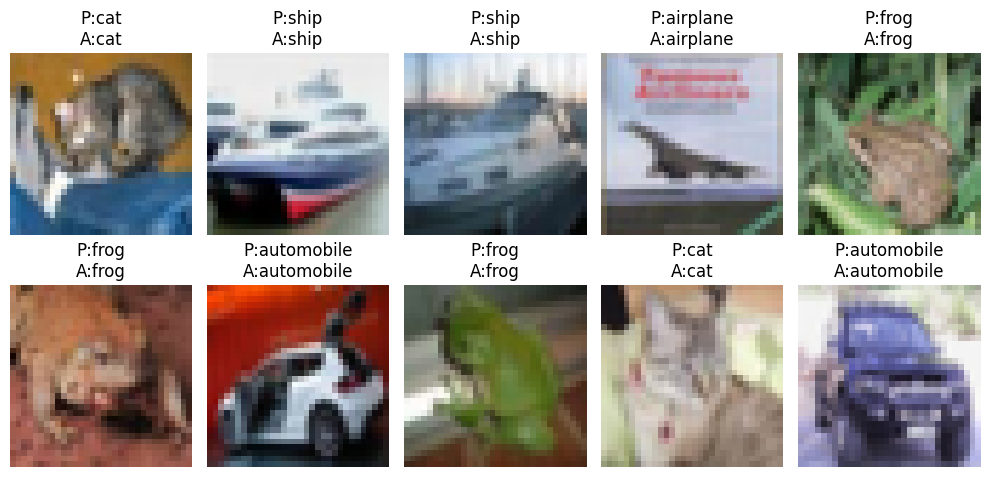

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_names = [
    'airplane','automobile','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
]

# Predict first 10 test images
predictions = model.predict(x_test[:10])

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    predicted_label = class_names[
        np.argmax(predictions[i])
    ]

    actual_label = class_names[
        y_test[i][0]
    ]

    plt.title(
        f"P:{predicted_label}\nA:{actual_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Below code is for second model

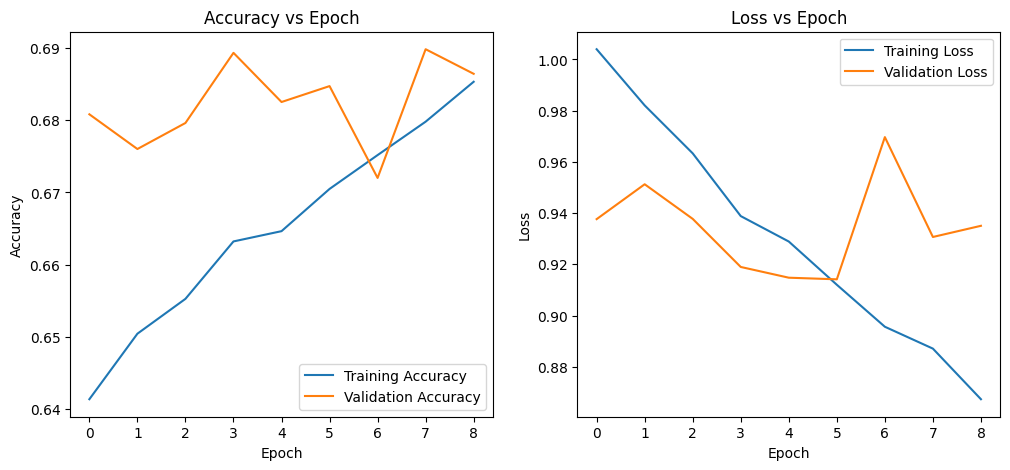

In [33]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history2.history['accuracy'],
         label='Training Accuracy')

plt.plot(history2.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history2.history['loss'],
         label='Training Loss')

plt.plot(history2.history['val_loss'],
         label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [54]:
from google.colab import files

uploaded = files.upload()

Saving cat2.jpg to cat2.jpg


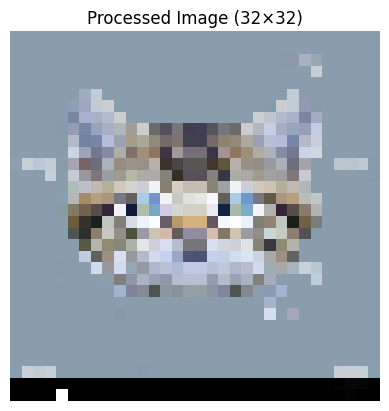

Input shape: (1, 32, 32, 3)


In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your uploaded image
img = cv2.imread("cat2.jpg")

# Convert BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to model input size
img_resized = cv2.resize(img, (32, 32))

# Normalize
img_normalized = img_resized / 255.0

# Reshape for CNN
img_input = img_normalized.reshape(1, 32, 32, 3)

# Show processed image
plt.imshow(img_resized)
plt.title("Processed Image (32×32)")
plt.axis('off')
plt.show()

# Print shape (important check)
print("Input shape:", img_input.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


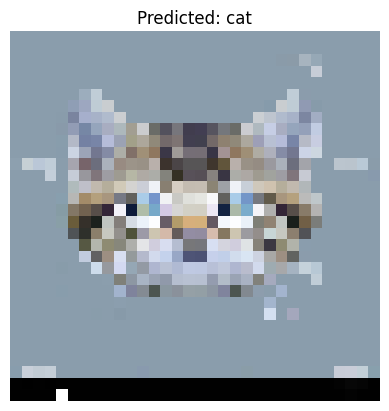

Predicted Animal: cat


In [56]:
# Class labels (same as before)
class_names = [
    'airplane','automobile','bird','cat',
    'deer','dog','frog','horse',
    'ship','truck'
]

# Predict
prediction = model.predict(img_input)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Get predicted label
predicted_label = class_names[predicted_index]

# Show result
plt.imshow(img_resized)
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

print("Predicted Animal:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


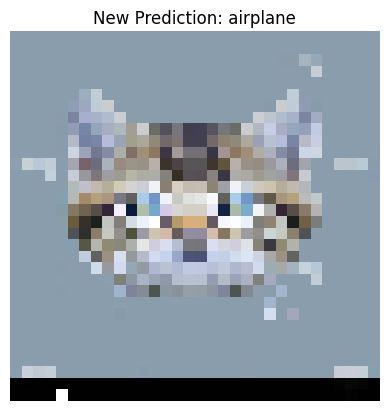

New Predicted Animal: airplane


In [58]:
# Predict using improved model
prediction2 = model2.predict(img_input)

# Get predicted class index
predicted_index2 = np.argmax(prediction2)

# Get predicted label
predicted_label2 = class_names[predicted_index2]

# Show result
plt.imshow(img_resized)
plt.title(f"New Prediction: {predicted_label2}")
plt.axis('off')
plt.show()

print("New Predicted Animal:", predicted_label2)